[*********************100%***********************]  5 of 5 completed
C:\Users\Sujay MS\AppData\Local\Temp\ipykernel_19988\707385452.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=volatility, ax=axes[1, 0], palette="viridis")


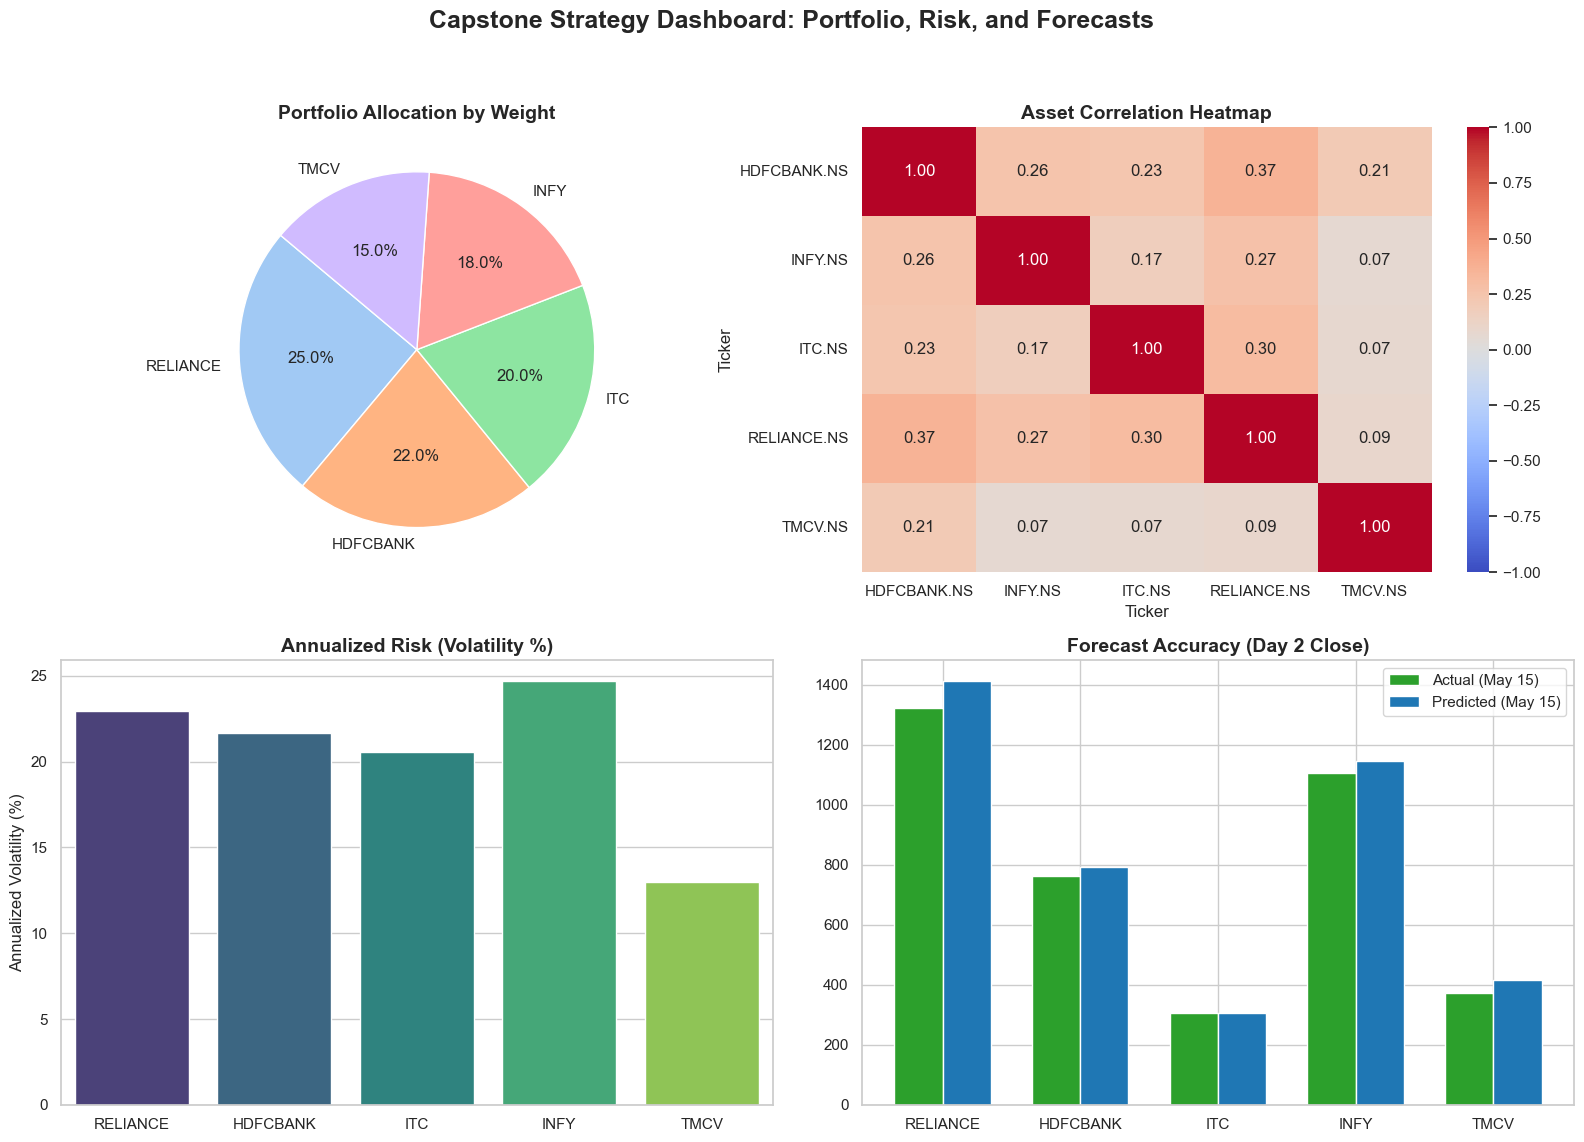

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf

# --- QUICK FIX: Re-fetch the data so this cell works completely on its own ---
tickers = ["RELIANCE.NS", "HDFCBANK.NS", "ITC.NS", "INFY.NS", "TMCV.NS"]
data_cleaned = yf.download(tickers, start="2021-01-01", end="2026-05-14", interval="1d")['Close'].ffill().bfill()
# --------------------------------------------------------------------------

# Set aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Capstone Strategy Dashboard: Portfolio, Risk, and Forecasts', fontsize=18, fontweight='bold')

# --- 1. Portfolio Allocation (Pie Chart) ---
labels = ['RELIANCE', 'HDFCBANK', 'ITC', 'INFY', 'TMCV']
weights = [25, 22, 20, 18, 15]
axes[0, 0].pie(weights, labels=labels, autopct='%1.1f%%', startangle=140, 
               colors=sns.color_palette("pastel")[0:5], wedgeprops={'edgecolor': 'white'})
axes[0, 0].set_title('Portfolio Allocation by Weight', fontsize=14, fontweight='bold')

# --- 2. Correlation Heatmap ---
# Calculates correlation using the historical data
returns = data_cleaned.pct_change().dropna()
corr_matrix = returns.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 1], vmin=-1, vmax=1)
axes[0, 1].set_title('Asset Correlation Heatmap', fontsize=14, fontweight='bold')

# --- 3. Trend and Volatility (Bar Chart) ---
# Extracted directly from your Task 4 results
volatility = [22.92, 21.68, 20.54, 24.68, 12.97] # Reliance, HDFC, ITC, INFY, TMCV
sns.barplot(x=labels, y=volatility, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title('Annualized Risk (Volatility %)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Annualized Volatility (%)')

# --- 4. Forecast vs Actual (Grouped Bar Chart) ---
# Extracted directly from your Task 8 live results
actual_prices = [1322.53, 762.33, 305.84, 1106.18, 372.90]
predicted_prices = [1411.20, 793.81, 305.90, 1144.41, 415.34]

x = np.arange(len(labels))
width = 0.35

axes[1, 1].bar(x - width/2, actual_prices, width, label='Actual (May 15)', color='#2ca02c')
axes[1, 1].bar(x + width/2, predicted_prices, width, label='Predicted (May 15)', color='#1f77b4')
axes[1, 1].set_title('Forecast Accuracy (Day 2 Close)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels)
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()